# Exploratory Data Analysis on Secondary Substations (PTDs)

In [1]:
import requests
import pandas as pandas
import time


In [12]:
# Use the exact URL you found, copy-pasted directly from your browser
url = "https://e-redes.opendatasoft.com/api/explore/v2.1/catalog/datasets/postos-transformacao-distribuicao/records"

headers = {
    "Accept": "application/json",        # explicitly tell the server we want JSON back
    "User-Agent": "Mozilla/5.0"          # some servers reject requests without this
}

params = {
    "limit": 5,
    "timezone": "Europe/Lisbon"
}

response = requests.get(url, headers=headers, params=params, timeout=30)

print("Status code:", response.status_code)
print("Content-Type:", response.headers.get("Content-Type"))
print("\nFirst 500 chars:")
print(response.text[:500])

Status code: 200
Content-Type: application/json; charset=utf-8

First 500 chars:
{"total_count": 72349, "results": [{"cod_instalacao": "0805D2055900", "dis_name": "Faro", "con_name": "Faro", "coordenadas_geo": {"lon": -7.858146369810557, "lat": 37.10952141720869}, "potencia_transformacao_kva": 100, "nivel_utilizacao": "0%-19%", "tipo_construtivo": "A\u00e9reo - AI", "potencia_contratada": "N/D", "num_clientes": "<20", "potencia_geracao": "N/D", "num_produtores": "<20", "histogram": "(0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;254.0;7969.0;123.75;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;


In [14]:
data = response.json()

# The API wraps results in a dict — let's see the top-level keys
print("Top-level keys:", data.keys())

# Total number of records in the full dataset
print("Total records available:", data.get("total_count"))

# Preview the first record
print("\nFirst record:")
print(data["results"][0])

Top-level keys: dict_keys(['total_count', 'results'])
Total records available: 72349

First record:
{'cod_instalacao': '0805D2055900', 'dis_name': 'Faro', 'con_name': 'Faro', 'coordenadas_geo': {'lon': -7.858146369810557, 'lat': 37.10952141720869}, 'potencia_transformacao_kva': 100, 'nivel_utilizacao': '0%-19%', 'tipo_construtivo': 'Aéreo - AI', 'potencia_contratada': 'N/D', 'num_clientes': '<20', 'potencia_geracao': 'N/D', 'num_produtores': '<20', 'histogram': '(0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;254.0;7969.0;123.75;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0)', 'coddistrito': '08', 'coddistritoconcelho': '0805'}


In [16]:
first_record = data["results"][0]

print("Fields in each record:")
for key, value in first_record.items():
    print(f" {key:45s} : {type(value).__name__:<10s} example: {str(value)[:60]}")

Fields in each record:
 cod_instalacao                                : str        example: 0805D2055900
 dis_name                                      : str        example: Faro
 con_name                                      : str        example: Faro
 coordenadas_geo                               : dict       example: {'lon': -7.858146369810557, 'lat': 37.10952141720869}
 potencia_transformacao_kva                    : int        example: 100
 nivel_utilizacao                              : str        example: 0%-19%
 tipo_construtivo                              : str        example: Aéreo - AI
 potencia_contratada                           : str        example: N/D
 num_clientes                                  : str        example: <20
 potencia_geracao                              : str        example: N/D
 num_produtores                                : str        example: <20
 histogram                                     : str        example: (0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0

In [34]:
import requests
import pandas as pd
import time

def load_ptd_porto(delay_seconds=0.2):
    BASE_URL = (
 "https://e-redes.opendatasoft.com/api/explore/v2.1/catalog/datasets/postos-transformacao-distribuicao/records"
    )
    LIMIT = 100
    MAX_OFFSET = 10000

    headers = {
        "Accept": "application/json",
        "User-Agent": "Mozilla/5.0"
    }

    # First call — check how many PTDs Porto has
    first = requests.get(
        BASE_URL,
        headers=headers,
        params={
            "limit": 1,
            "offset": 0,
            "where": 'dis_name="Porto"'
        },
        timeout=30
    )
    first.raise_for_status()
    total = first.json().get("total_count", 0)
    print(f"Total PTDs in Porto district: {total}")

    if total > MAX_OFFSET:
        print(f"WARNING: Porto has {total} records — over the 10,000 cap.")
        print("We will fetch the first 10,000. Tell me and we'll split by municipality.")

    all_records = []
    offset = 0
    fetchable = min(total, MAX_OFFSET)

    while offset < fetchable:
        current_limit = min(LIMIT, MAX_OFFSET - offset)

        response = requests.get(
            BASE_URL,
            headers=headers,
            params={
                "limit": current_limit,
                "offset": offset,
                "where": 'dis_name="Porto"'
            },
            timeout=30
        )

        if response.status_code != 200:
            print(f"Failed at offset {offset}: {response.text[:200]}")
            break

        batch = response.json().get("results", [])
        if not batch:
            break

        all_records.extend(batch)
        offset += len(batch)

        pct = offset / fetchable * 100
        print(f"  Progress: {offset}/{fetchable} ({pct:.0f}%)", end="\r")

        time.sleep(delay_seconds)

    print(f"\nDone. Fetched {len(all_records)} PTDs in Porto.")
    return pd.DataFrame(all_records)


df_raw = load_ptd_porto()

Total PTDs in Porto district: 9064
  Progress: 9064/9064 (100%)
Done. Fetched 9064 PTDs in Porto.


In [35]:
print(f"Rows: {df_raw.shape[0]}")
print(f"Columns: {df_raw.shape[1]}")
print(f"\nColumn names:")
for col in df_raw.columns:
    print(f"  {col}")

Rows: 9064
Columns: 14

Column names:
  cod_instalacao
  dis_name
  con_name
  coordenadas_geo
  potencia_transformacao_kva
  nivel_utilizacao
  tipo_construtivo
  potencia_contratada
  num_clientes
  potencia_geracao
  num_produtores
  histogram
  coddistrito
  coddistritoconcelho


In [36]:
df_raw.head()

,cod_instalacao,dis_name,con_name,coordenadas_geo,potencia_transformacao_kva,nivel_utilizacao,tipo_construtivo,potencia_contratada,num_clientes,potencia_geracao,num_produtores,histogram,coddistrito,coddistritoconcelho
0,1311D2018500,Porto,Penafiel,"{'lon': -8.218044058979634, 'lat': 41.23882382...",250,20%-39%,Cabine alta,603.92,77,N/D,<20,(0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;304.5...,13,1311
1,1311D2038300,Porto,Penafiel,"{'lon': -8.235763053474876, 'lat': 41.15574985...",160,20%-39%,Aéreo - AI,N/D,<20,N/D,<20,(0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;4303....,13,1311
2,1312D2103900,Porto,Porto,"{'lon': -8.609953901947133, 'lat': 41.18466106...",400,N/D,Cabine baixa em edifício próprio,662.19,129,N/D,<20,None,13,1312
3,1312D2047400,Porto,Porto,"{'lon': -8.60395239332418, 'lat': 41.148680409...",630,20%-39%,Cabine baixa integrada em edifício,625.60,102,N/D,<20,(0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;1749....,13,1312
4,1317D2034000,Porto,Vila Nova de Gaia,"{'lon': -8.547110245510458, 'lat': 41.03692734...",630,20%-39%,Cabine alta,1006.78,129,N/D,<20,(0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;0.0;3938....,13,1317


In [37]:
df_raw.columns.tolist()


['cod_instalacao',
 'dis_name',
 'con_name',
 'coordenadas_geo',
 'potencia_transformacao_kva',
 'nivel_utilizacao',
 'tipo_construtivo',
 'potencia_contratada',
 'num_clientes',
 'potencia_geracao',
 'num_produtores',
 'histogram',
 'coddistrito',
 'coddistritoconcelho']

In [38]:
import re

# Rename to clean English
df = df_raw.rename(columns={
    "cod_instalacao"          : "ptd_id",
    "dis_name"                : "district",
    "con_name"                : "municipality",
    "coordenadas_geo"         : "geo",
    "potencia_transformacao_kva" : "installed_kva",
    "nivel_utilizacao"        : "utilization_band",
    "tipo_construtivo"        : "construction_type",
    "potencia_contratada"     : "contracted_kva",
    "num_clientes"            : "n_clients",
    "potencia_geracao"        : "pv_kw",
    "num_produtores"          : "n_producers",
}).copy()

# Extract lat/lon from the geo dict
df["lat"] = df["geo"].apply(lambda x: x.get("lat") if isinstance(x, dict) else None)
df["lon"] = df["geo"].apply(lambda x: x.get("lon") if isinstance(x, dict) else None)
df.drop(columns=["geo", "histogram", "coddistrito", "coddistritoconcelho"], inplace=True)

# Parse utilization band → numeric midpoint
def parse_utilization(band):
    if pd.isna(band) or str(band).strip() == "":
        return None
    band = str(band).strip()
    if band.startswith(">"):
        nums = re.findall(r"\d+", band)
        return float(nums[0]) + 9.5 if nums else None
    if band.startswith("<"):
        nums = re.findall(r"\d+", band)
        return float(nums[0]) / 2 if nums else None
    nums = re.findall(r"\d+", band)
    if len(nums) >= 2:
        return (float(nums[0]) + float(nums[1])) / 2
    return None

df["utilization_pct"] = df["utilization_band"].apply(parse_utilization)

# Cast numeric columns
for col in ["installed_kva", "contracted_kva", "n_clients", "pv_kw", "n_producers"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Compute headroom
df["headroom_kva"] = (df["installed_kva"] * (1 - df["utilization_pct"] / 100)).clip(lower=0)

print("Shape:", df.shape)
df.head(3)

Shape: (9064, 14)


,ptd_id,district,municipality,installed_kva,utilization_band,construction_type,contracted_kva,n_clients,pv_kw,n_producers,lat,lon,utilization_pct,headroom_kva
0,1311D2018500,Porto,Penafiel,250,20%-39%,Cabine alta,603.92,77.0,NaN,NaN,41.238824,-8.218044,29.5,176.25
1,1311D2038300,Porto,Penafiel,160,20%-39%,Aéreo - AI,NaN,NaN,NaN,NaN,41.155750,-8.235763,29.5,112.80
2,1312D2103900,Porto,Porto,400,N/D,Cabine baixa em edifício próprio,662.19,129.0,NaN,NaN,41.184661,-8.609954,NaN,NaN


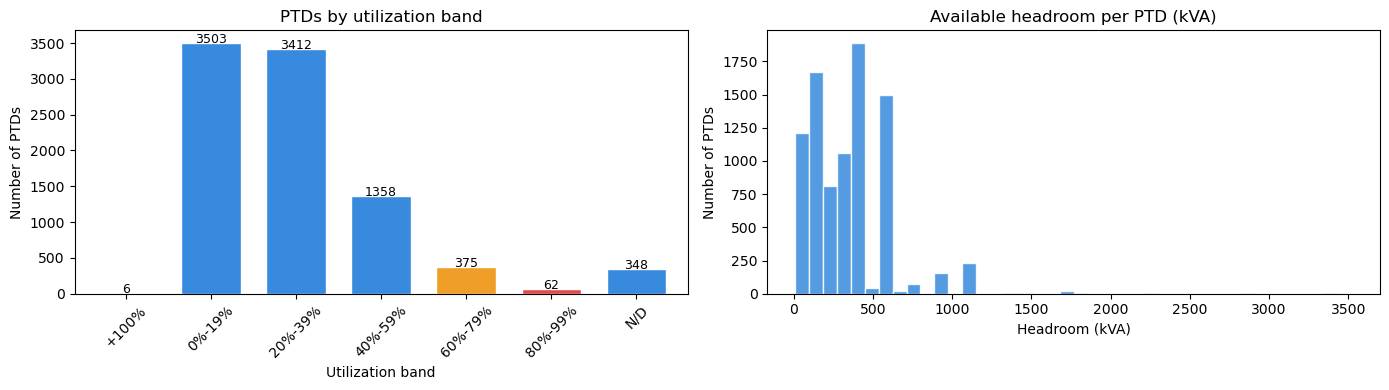

Total PTDs          : 9064
Critical  (≥80%)    : 62  (0.7%)
Moderate  (60-79%)  : 375  (4.1%)
Healthy   (<60%)    : 8273  (91.3%)
Missing utilization : 354  (3.9%)


In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: count per utilization band
band_order = sorted(df["utilization_band"].dropna().unique())
band_counts = df["utilization_band"].value_counts().reindex(band_order, fill_value=0)

colors = []
for b in band_order:
    nums = re.findall(r"\d+", str(b))
    low = int(nums[0]) if nums else 0
    if low >= 80:   colors.append("#E24B4A")   # red — critical
    elif low >= 60: colors.append("#EF9F27")   # amber — moderate
    else:           colors.append("#378ADD")   # blue — healthy

band_counts.plot(kind="bar", ax=axes[0], color=colors, edgecolor="white", width=0.7)
axes[0].set_title("PTDs by utilization band", fontsize=12)
axes[0].set_xlabel("Utilization band")
axes[0].set_ylabel("Number of PTDs")
axes[0].tick_params(axis="x", rotation=45)

# Annotate counts on bars
for i, v in enumerate(band_counts):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontsize=9)

# Right: headroom distribution
df["headroom_kva"].dropna().plot(
    kind="hist", bins=40, ax=axes[1],
    color="#378ADD", edgecolor="white", alpha=0.85
)
axes[1].set_title("Available headroom per PTD (kVA)", fontsize=12)
axes[1].set_xlabel("Headroom (kVA)")
axes[1].set_ylabel("Number of PTDs")

plt.tight_layout()
plt.show()

# Summary numbers
total = len(df)
critical = (df["utilization_pct"] >= 80).sum()
moderate = ((df["utilization_pct"] >= 60) & (df["utilization_pct"] < 80)).sum()
healthy  = (df["utilization_pct"] < 60).sum()
missing  = df["utilization_pct"].isna().sum()

print(f"Total PTDs          : {total}")
print(f"Critical  (≥80%)    : {critical}  ({critical/total*100:.1f}%)")
print(f"Moderate  (60-79%)  : {moderate}  ({moderate/total*100:.1f}%)")
print(f"Healthy   (<60%)    : {healthy}  ({healthy/total*100:.1f}%)")
print(f"Missing utilization : {missing}  ({missing/total*100:.1f}%)")

In [41]:
# PTDs that are critical AND have no PV yet — prime candidates
candidates = df[
    (df["utilization_pct"] >= 60)   # moderate or critical load
].copy()

candidates["priority_score"] = (
    candidates["utilization_pct"] * 0.6 +   # weight: how overloaded
    candidates["n_clients"]       * 0.4     # weight: how many people affected
)

candidates_sorted = candidates.sort_values("priority_score", ascending=False)

print(f"PTDs with ≥60% load and no PV: {len(candidates)}")
print(f"\nTop 15 priority PTDs for PV installation:")
display(candidates_sorted[[
    "ptd_id", "municipality", "installed_kva",
    "utilization_pct", "headroom_kva",
    "n_clients", "priority_score"
]].head(15).round(1))

PTDs with ≥60% load and no PV: 437

Top 15 priority PTDs for PV installation:


,ptd_id,municipality,installed_kva,utilization_pct,headroom_kva,n_clients,priority_score
4262,1316D2004200,Vila do Conde,630,69.5,192.2,751.0,342.1
801,1313D2004000,Póvoa de Varzim,400,69.5,122.0,438.0,216.9
6101,1312D2014600,Porto,400,69.5,122.0,431.0,214.1
5411,1313D2008700,Póvoa de Varzim,200,69.5,61.0,425.0,211.7
5646,1308D2015100,Matosinhos,630,69.5,192.2,413.0,206.9
4689,1308D2002500,Matosinhos,630,69.5,192.2,411.0,206.1
3827,1315D2005500,Valongo,400,69.5,122.0,394.0,199.3
4730,1308D2023400,Matosinhos,400,69.5,122.0,373.0,190.9
5782,1309D2018000,Paços de Ferreira,250,89.5,26.2,338.0,188.9
7300,1316D2009100,Vila do Conde,400,69.5,122.0,358.0,184.9
